In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import yfinance as yf
from datetime import date

In [2]:
start_date = "2024-01-01"
end_date = date.today().strftime("%Y-%m-%d")
dataFrame = yf.download('BTC-USD',start=start_date,end=end_date,interval='1d')
print(f"dữ liệu từ: {start_date} đến {end_date}:")
print(dataFrame.head())

[*********************100%***********************]  1 of 1 completed

dữ liệu từ: 2024-01-01 đến 2026-05-04:
Price              Close          High           Low          Open  \
Ticker           BTC-USD       BTC-USD       BTC-USD       BTC-USD   
Date                                                                 
2024-01-01  44167.332031  44175.437500  42214.976562  42280.234375   
2024-01-02  44957.968750  45899.707031  44176.949219  44187.140625   
2024-01-03  42848.175781  45503.242188  40813.535156  44961.601562   
2024-01-04  44179.921875  44770.023438  42675.175781  42855.816406   
2024-01-05  44162.691406  44353.285156  42784.718750  44192.980469   

Price            Volume  
Ticker          BTC-USD  
Date                     
2024-01-01  18426978443  
2024-01-02  39335274536  
2024-01-03  46342323118  
2024-01-04  30448091210  
2024-01-05  32336029347  


In [3]:
df = dataFrame.copy()

In [4]:
df.tail(5)

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-04-28,76350.671875,77483.867188,75673.601562,77368.117188,32056900880
2026-04-29,75776.132812,77884.968750,74958.570312,76350.687500,41460907886
2026-04-30,76304.320312,76611.484375,75318.984375,75778.632812,29497862305
2026-05-01,78179.000000,78894.976562,76294.695312,76305.054688,39164328894
2026-05-02,78657.250000,79119.789062,78031.960938,78177.750000,16761531851


In [5]:
df = df.reset_index()
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

In [6]:
df.to_csv('bticoin_dataset.csv',index=False,encoding='utf-8-sig')
print("đã xuất file thành công: bitcoin_dataset.csv")

đã xuất file thành công: bitcoin_dataset.csv


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Date, )           853 non-null    object 
 1   (Close, BTC-USD)   853 non-null    float64
 2   (High, BTC-USD)    853 non-null    float64
 3   (Low, BTC-USD)     853 non-null    float64
 4   (Open, BTC-USD)    853 non-null    float64
 5   (Volume, BTC-USD)  853 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 40.1+ KB


In [8]:
df.shape

(853, 6)

In [9]:
df.columns

MultiIndex([(  'Date',        ''),
            ( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [10]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,853.000000,853.000000,853.000000,853.000000,8.530000e+02
mean,82645.317821,84052.354438,81089.052274,82602.451898,4.469711e+10
std,21088.843357,21263.999395,20933.197838,21133.686367,2.339095e+10
min,39507.367188,40127.351562,38521.894531,39518.714844,9.344044e+09
25%,65887.648438,67232.859375,64547.847656,65878.929688,2.799127e+10
50%,83684.976562,84696.148438,81529.242188,83694.523438,4.035490e+10
75%,100655.906250,102618.882812,97926.148438,100661.539062,5.590319e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,1.817464e+11


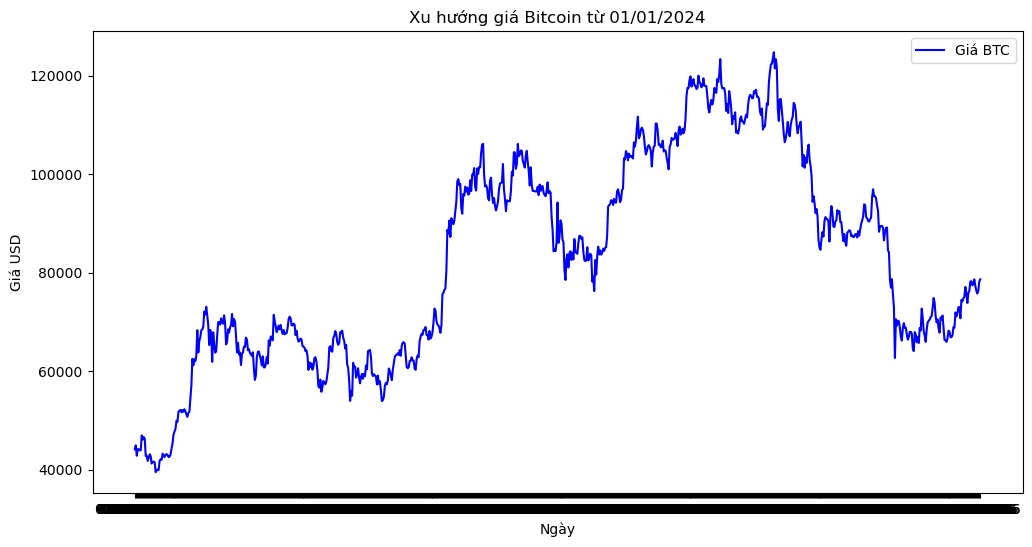

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], color='blue', label='Giá BTC')
plt.title('Xu hướng giá Bitcoin từ 01/01/2024')
plt.xlabel('Ngày')
plt.ylabel('Giá USD')
plt.legend()
plt.show()

In [12]:
import plotly.express as px
fig = px.line(df, x='Date', y=df['Close'].squeeze(), title='Xu hướng giá Bitcoin từ 01/01/2024')

fig.update_traces(line_color='blue') 
fig.update_layout(xaxis_title='Ngày', yaxis_title='Giá USD')
fig.show()

In [13]:
num_missing = df.isnull().sum()
num_missing[num_missing >0]

Series([], dtype: int64)

In [14]:
df_new = df.drop('Date',axis=1)
df_new

C:\Users\NKAQuoc002\AppData\Local\Temp\ipykernel_17892\3761395593.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
1,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
3,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
4,44162.691406,44353.285156,42784.718750,44192.980469,32336029347
...,...,...,...,...,...
848,76350.671875,77483.867188,75673.601562,77368.117188,32056900880
849,75776.132812,77884.968750,74958.570312,76350.687500,41460907886
850,76304.320312,76611.484375,75318.984375,75778.632812,29497862305


In [15]:
split_index = int(len(df_new)*0.8)
data_train = df_new.iloc[:split_index]
data_test = df_new.iloc[split_index:]

print(f"Số mẫu Train: {len(data_train)}")
print(f"Số mẫu Test: {len(data_test)}")

Số mẫu Train: 682
Số mẫu Test: 171


In [16]:
X_train = data_train.drop('Close', axis=1)
y_train = data_train['Close']

X_test = data_test.drop('Close', axis=1)
y_test = data_test['Close']

X_train.shape, y_train.shape

((682, 4), (682, 1))

In [17]:
y_train = y_train.values.ravel()
print(X_train.shape)
print(y_train.shape)

y_test = y_test.values.ravel()
print(y_test.shape)

(682, 4)
(682,)
(171,)


In [18]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [19]:
def relative_error(y_true, y_pred):
    errors = np.abs(y_pred - y_true).astype(float) / y_true
    return np.mean(errors)*100

In [20]:
y_pred = model.predict(X_test)
pd.DataFrame(data=np.array([y_test, y_pred, abs(y_test - y_pred)]).T, columns=["Thực tế", "Dự đoán", "Lệch"])

,Thực tế,Dự đoán,Lệch
0,99697.492188,102694.819141,2997.326953
1,94397.789062,97148.692031,2750.902969
2,95549.148438,96013.205703,464.057266
3,94177.078125,94947.170313,770.092188
4,92093.875000,92674.740859,580.865859
...,...,...,...
166,76350.671875,76850.165391,499.493516
167,75776.132812,76619.275625,843.142812
168,76304.320312,76421.214766,116.894453
169,78179.000000,76778.775000,1400.225000


In [25]:
from sklearn.metrics import mean_squared_error
print ('RMSE: {:.2f}'.format(sqrt(mean_squared_error(y_test, y_pred))))
print ('Mean relative errors: {:.1f}%'.format(relative_error(y_test, y_pred)))

RMSE: 1075.94
Mean relative errors: 1.1%


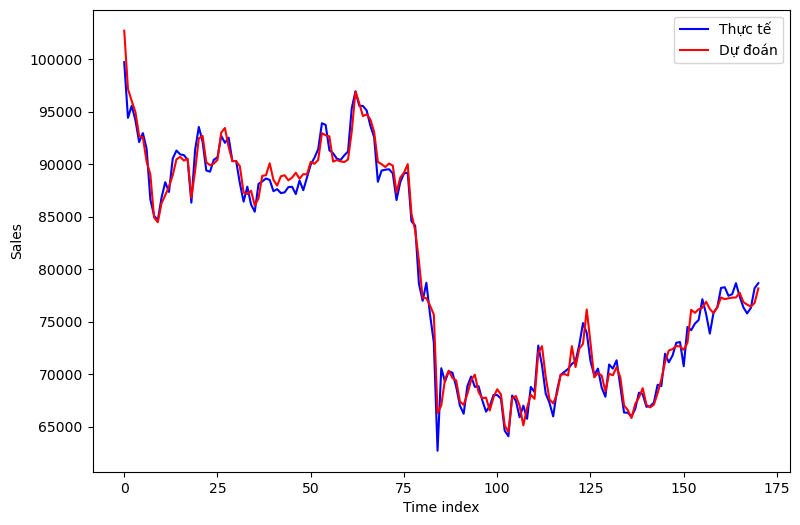

In [22]:
plt.figure(figsize=(9,6))
plt.plot(y_test, color='blue', label='Thực tế')
plt.plot(y_pred, color='red', label='Dự đoán')
plt.xlabel('Time index')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [23]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(y=y_test, mode='lines', name='Thực tế'))
fig.add_trace(go.Scatter(y=y_pred, mode='lines', name='Dự đoán'))

fig.show()